# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [2]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/" + "train.jsonl", lines=True)  # YOUR CODE HERE

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["sci.space", "comp.graphics", "misc.forsale"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['sci.space', 'comp.graphics', 'misc.forsale']
Filtered dataset size: 1762


In [7]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = re.sub(r'\S+@\S+', '', text.lower())  # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)  # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) >= 3]
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [9]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1762 documents
Total tokens: 146796

Sample document tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


In [10]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 4475


In [11]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 4475


### A.2 Exploring Word Embeddings

In [12]:
# Example: Get word vector
sample_word = "space"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [-0.6506502   0.03817166 -0.43121788  0.0900907   0.3724809  -1.1328114
  0.886273    0.24184543 -0.4187739   1.0840576 ]


In [13]:
# Find similar words
sample_word = "space"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  nasa: 0.9758
  center: 0.9602
  national: 0.9491
  science: 0.9403
  technology: 0.9303
  research: 0.9237
  shuttle: 0.9116
  station: 0.9022
  institute: 0.8972
  office: 0.8972

Words most similar to 'space' (Skip-gram):
  nasajscgm: 0.6024
  camp: 0.6020
  jenks: 0.5968
  national: 0.5934
  office: 0.5929
  nasp: 0.5913
  defense: 0.5909
  jsc: 0.5905
  administration: 0.5882
  cooperation: 0.5841


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [14]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["space", "image", "sale", "orbit", "graphic"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'space':
  CBOW:     ['nasa', 'center', 'national', 'science', 'technology']
  Skip-gram: ['nasajscgm', 'camp', 'jenks', 'national', 'office']

'image':
  CBOW:     ['display', 'jpeg', 'gif', 'bit', 'processing']
  Skip-gram: ['lossless', 'gif', 'manipulation', 'setting', 'fullcolor']

'sale':
  CBOW:     ['game', 'price', 'asking', 'box', 'condition']
  Skip-gram: ['polk', 'roland', 'onkyo', 'sipps', 'upgraded']

'orbit':
  CBOW:     ['earth', 'lunar', 'mar', 'probe', 'rocket']
  Skip-gram: ['circular', 'gravitational', 'inclination', 'polar', 'maneuver']

'graphic':
  CBOW:     ['software', 'library', 'package', 'run', 'unix']
  Skip-gram: ['exponent', 'radiosity', 'silicon', 'workshop', 'gem']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: space and image showed the most similar results between both models. For space both found nasa and national, and for image both found gif and processing related words.

2. Different results for: sale, orbit and graphic gave very different results. For sale CBOW found general selling words like price and condition while Skip-gram found specific brand names like roland and onkyo. For orbit CBOW found nearby planets while Skip-gram found more technical terms like inclination and maneuver.

3. Better model for my domain: CBOW seems to work better for these 3 categories.
      * Example 1: For orbit, CBOW returned earth, lunar and rocket which are clearly related space words, while Skip-gram returned very technical niche terms that are less intuitive.
      * Example 2: For image, CBOW returned jpeg, gif and display which are the most common and useful words in comp.graphics context, while Skip-gram returned mless used words like fullcolor and manipulation.

4. Explanation of differences: CBOW works better with frequent words because it predicts a word from its context, so it captures general relationships well. Skip-gram works better with rare or specific words because it predicts context from a word, which is why it found brand names like roland and onkyo for sale, and very technical terms like inclination for orbit. Since the dataset is small, frequent words benefit more from CBOW while rare domain-specific words are better captured by Skip-gram.

### A.3 Word Analogies

In [17]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
result = find_analogy(model_skipgram, "science", "launch", "orbit")
print(result)

Analogy test (your model may have limited vocabulary):
[('pad', 0.6614972949028015), ('vehicle', 0.6581984758377075), ('proton', 0.6389713883399963), ('leo', 0.6372180581092834), ('abort', 0.6063472032546997)]


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [18]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "science", "launch", "orbit")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "image", "format", "file")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('pad', 0.6614972949028015), ('vehicle', 0.6581984758377075), ('proton', 0.6389713883399963), ('leo', 0.6372180581092834), ('abort', 0.6063472032546997)]
Analogy 2: [('hsi', 0.6336027979850769), ('motecc', 0.615996241569519), ('temp', 0.6071439981460571), ('plain', 0.6059874892234802), ('jfif', 0.6006590127944946)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Analyze your analogy results]*

Analogy 1 worked well. The results like pad, vehicle, proton and leo (low earth orbit) all make sense in a space launch context, showing the model learned good relationships between space related words.
Analogy 2 partially worked. jfif is actually an image file format which makes sense, but words like hsi and motecc are very specific and probably appeared rarely in the dataset, so the model did not learn strong relationships for file format vocabulary. This is mainly because our dataset is small and comp.graphics posts are fewer than sci.space ones.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [19]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [20]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  nasajscgm: 0.6024
  camp: 0.6020
  jenks: 0.5968
  national: 0.5934
  office: 0.5929
  nasp: 0.5913
  defense: 0.5909
  jsc: 0.5905
  administration: 0.5882
  cooperation: 0.5841

Pre-trained GloVe:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [21]:
# TODO: Compare 3 domain-specific words

comparison_words = ["orbit", "image", "sale"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'orbit'
Your Word2Vec:
  circular: 0.827
  gravitational: 0.825
  inclination: 0.824
  polar: 0.820
  maneuver: 0.816
GloVe:
  spacecraft: 0.807
  orbits: 0.804
  orbiting: 0.761
  orbital: 0.733
  satellites: 0.713

Word: 'image'
Your Word2Vec:
  lossless: 0.742
  gif: 0.729
  manipulation: 0.724
  setting: 0.715
  fullcolor: 0.711
GloVe:
  images: 0.734
  picture: 0.728
  symbol: 0.673
  color: 0.662
  seen: 0.660

Word: 'sale'
Your Word2Vec:
  polk: 0.752
  roland: 0.751
  onkyo: 0.748
  sipps: 0.747
  upgraded: 0.736
GloVe:
  purchase: 0.855
  sell: 0.813
  auction: 0.765
  buy: 0.739
  sold: 0.736


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: orbit, because it found very specific technical terms like circular, gravitational and inclination that are highly relevant in a space physics context.
   - Reason: The custom model was trained specifically on these 3 categories so it learned the niche vocabulary that appears frequently in those posts, even if those words are not common in general English.

2. GloVe is better for: sale and image, because it found more intuitive and natural related words like purchase, sell, auction for sale, and picture and color for image.
   - Reason: GloVe was trained on hundreds of millions of words so it understands general word meaning much better and captures broader and more natural relationships for common words.

3. When to use each:
   - Custom model: When your text has very specific vocabulary that does not appear in general language, like medical terms, legal documents, or niche technical forum posts like in this dataset.
   - Pre-trained model: When you need to understand general language meaning, when your dataset is small, or when you need a quick and reliable solution without training from scratch.

### B.2 GloVe Analogies

In [ ]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

In [22]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: rocket is to launch as ship is to ?
result1 = glove_model.most_similar(positive=['launch', 'ship'], negative=['rocket'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2
# YOUR CODE HERE
result2 = glove_model.most_similar(positive=['image', 'video'], negative=['photo'], topn=3)
print("Analogy 2:")
print(result2)

# Analogy 3
# YOUR CODE HERE
result3 = glove_model.most_similar(positive=['sale', 'buy'], negative=['sell'], topn=3)
print("Analogy 3:")
print(result3)

Analogy 1:
[('ships', 0.6881340146064758), ('vessel', 0.6707022786140442), ('sail', 0.6492987275123596)]
Analogy 2:
[('reality', 0.6206396818161011), ('images', 0.6070067882537842), ('console', 0.6033960580825806)]
Analogy 3:
[('purchase', 0.8792821168899536), ('acquisition', 0.7326626181602478), ('buying', 0.7314091920852661)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [23]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [24]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [25]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [26]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [27]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)  # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


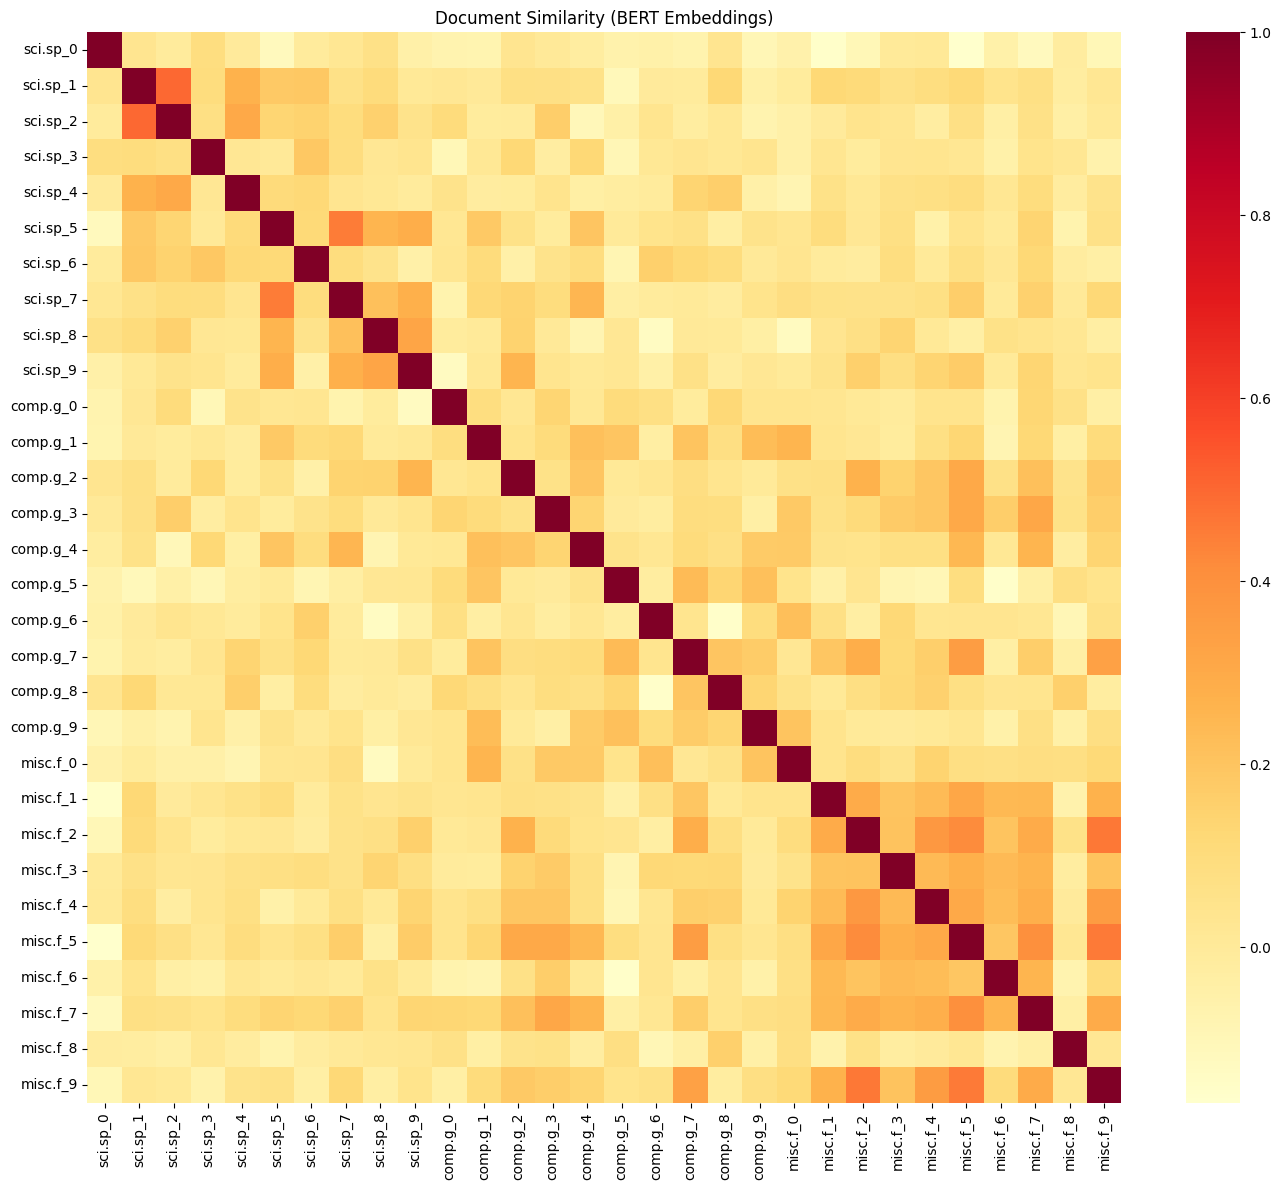

In [28]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: TF-IDF showed cleaner and more defined clusters in this case. The BERT heatmap has more orange tones across the entire matrix, meaning BERT sees more general similarity between all documents regardless of category. TF-IDF had a clearer separation with most of the matrix being light yellow and only the diagonal blocks being dark red.

2. Differences between methods: BERT considers many more document pairs as moderately similar across different categories, while TF-IDF kept most cross-category similarities close to 0. This happens because BERT understands general language patterns and sentence structure, so documents that share a conversational tone can seem similar even if they are about completely different topics. TF-IDF only looks at exact word matches so it is stricter about what counts as similar.

3. Preferred method for classification: For this specific dataset I would use TF-IDF because the 3 categories have very distinct vocabularies and TF-IDF captured those differences more clearly. However for a more complex dataset where categories share similar vocabulary but have different meanings, BERT would be the better choice since it understands context and meaning beyond just word counts.

### Exercise C.2: Semantic Search with BERT

In [29]:
def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # YOUR CODE HERE
    # 1. Encode the query
    query_embedding = model.encode([query])
    # 2. Compute similarity with all documents
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    # 3. Return top_k most similar
    top_indices = similarities.argsort()[::-1][:top_k]
    return [(int(idx), float(similarities[idx])) for idx in top_indices]

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "rocket launch into space orbit"  # YOUR QUERY HERE

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'rocket launch into space orbit'

Top 5 most similar documents:

  Score: 0.2853
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.2366
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.1620
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.1130
  Category: sci.space
  Text: 
There was a recession, and none of the potential entrants could raise any
money.  The race organizers were actually supposed to be handling part of
t...

  Score: 0.0757
  Category: sci.space
  Text: 

He's also the one who dubbed it the SR-71 - it was the RS-71 until LBJ
mipps

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: The results are mostly relevant. The top 2 results are clearly about space and rocket launches, mentioning Kennedy Space Center and solid rocket boosters which match the query well. The 3rd and 4th results are less directly related to rocket launches but still about NASA and space funding, which is still within the sci.space topic. The last result is the weakest with a score of only 0.07 showing BERT was not very confident about it.

2. Category accuracy: Yes, all 5 results came from sci.space which is exactly the expected category for a query about rocket launches and orbit. This shows BERT did a good job identifying the right category even though the similarity scores are relatively low, which is expected given the small dataset size.

3. Ambiguous query test: A query like "computer system data file" could match both sci.space and comp.graphics since both categories use technical vocabulary like system and data. In that case BERT would likely return a mix of documents from both categories since it cannot rely on specific keywords alone and instead looks at the general meaning and context of the sentence.

---

## Part D: Embedding Visualization with t-SNE

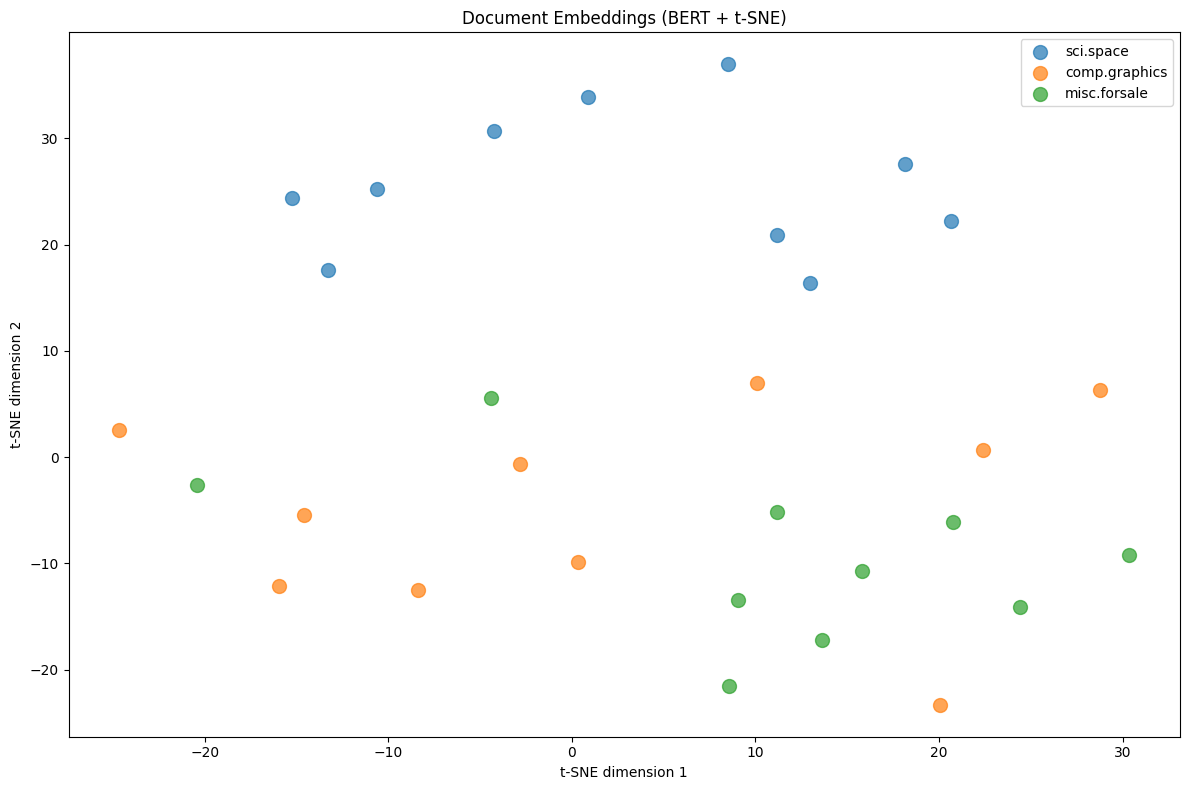

In [30]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

   1. Cluster quality: The categories do not form very distinct clusters. sci.space is the most grouped together, mostly in the upper part of the plot. However comp.graphics and misc.forsale are quite mixed together in the lower and middle areas, which means BERT did not separate them as clearly as TF-IDF did in Part 1.

   2. Misplaced documents: Yes, there are a few documents that appear far from their category group. For example there is 1 misc.forsale point in the upper left area close to comp.graphics points, and 1 comp.graphics point near the bottom mixed with misc.forsale. This could happen because those specific documents used more general language that is not very representative of their category, making BERT place them closer to other categories.

   3. Most similar categories: comp.graphics and misc.forsale appear to be the most similar based on the visualization since their points are the most mixed together. This is somewhat surprising compared to Part 1 where TF-IDF showed them as clearly different. It might be because both categories have a conversational and informal tone in their posts, which BERT picks up on even if the actual vocabulary is very different.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple and fast, easy to implement | Ignores word meaning and order, produces very large vectors | Simple text classification with distinct vocabularies |
| TF-IDF | Highlights important and unique words, reduces weight of common words | Still ignores meaning and context, struggles with synonyms | Document classification and keyword extraction |
| Word2Vec | Captures semantic relationships between words, compact vectors | Requires large data to train well, 1 vector per word regardless of context | Finding similar words, domain-specific NLP tasks |
| GloVe | Pre-trained on massive data, good general word relationships | Not contextual, same vector for a word in any context | General NLP tasks when no domain-specific training data is available |
| BERT | Understands context and meaning, best semantic understanding | Slow and computationally expensive, needs more resources | Complex NLP tasks where meaning and context matter |

2. Best Method for My Dataset

TF-IDF worked best overall for these 3 specific categories. The evidence is clear from the similarity heatmap in Part 1 where TF-IDF produced very clean and well separated clusters for sci.space, comp.graphics and misc.forsale. The top TF-IDF words for each category were also very representative, with words like nasa, orbit and launch for sci.space, and sale, offer and shipping for misc.forsale. BERT on the other hand struggled to clearly separate comp.graphics from misc.forsale as seen in the t-SNE visualization. This is because the 3 categories have very distinct vocabularies, which is exactly where TF-IDF performs best.

3. My Recommendation for a Real System

For a real classification system with these 3 categories I would use TF-IDF. The categories have very different and specific vocabularies so counting and weighting words is enough to tell them apart without needing complex models. TF-IDF is also much faster and cheaper to run than BERT, which matters in a real production system. However if the system needed to handle more categories with overlapping vocabulary, or needed to understand the meaning behind sentences, then BERT would be the better long term choice.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found